# HR Attrition — Decision Tree & Random Forest Modeling

**Author:** Mintay Misgano, Ph.D. | People Analytics | I-O Psychology  
**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 variables)  
**Tools:** Python · scikit-learn · pandas · seaborn · SMOTE / ADASYN

---

## Notebook Overview

This is the second notebook in the IBM HR Attrition project. Using the cleaned and preprocessed 
data from `01_EDA_and_Preprocessing.ipynb`, this notebook builds and evaluates classification 
models to predict which employees are at highest risk of leaving.

**Models covered:**
- Decision Tree Classifier (with hyperparameter tuning via max depth)
- Random Forest Classifier
- Comparison across original, SMOTE-balanced, and ADASYN-balanced datasets

**Key techniques:**
- Train/test split and cross-validation
- Handling class imbalance (attrition base rate ~16%) using oversampling
- Feature importance extraction from tree-based models
- Model evaluation: accuracy, precision, recall, confusion matrix

**Applied context:** Predicting attrition risk is a core use case in People Analytics — 
enabling proactive retention interventions before high-performing employees leave.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import * # import all libraries under sklearn.metrics
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import *
plt.rc("font", size=14)

sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)



# See #1137: this allows compatibility for scikit-learn >= 0.24
import sklearn.utils
from sklearn.utils import safe_indexing
# except ImportError:
# from sklearn.utils import _safe_indexing

# Oversample and plot imbalanced dataset with ADASYN
from collections import Counter
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import pyplot
from numpy import where


%matplotlib inline


# 2 functions to print out metrics (written by us, not in sklearn)

# define a function for calculating the metric to be used later 
# takes in 2 inputs: Y_pred, Y_true
# and uses them to calculate metrics using functions in sklearn
def classification_metrics(Y_pred, Y_true):
    acc = accuracy_score(Y_true, Y_pred)
    precision = precision_score(Y_true, Y_pred)
    recall = recall_score(Y_true, Y_pred)
    f1score = f1_score(Y_true, Y_pred)
    auc = roc_auc_score(Y_true, y_pred)

    # the function's outputs are the 5 variables below
    return acc, precision, recall, f1score, auc

# define a function for printing the metrics using inputs: classifierName, Y_pred, Y_true
# e.g. inputs can be: 'Logistic Regression', y_pred, y_test
# inside the function, we do something with the inputs (e.g. run classification_metrics on the inputs)
# classification_metrics is antoher function we wrote above
def display_metrics(classifierName, Y_pred, Y_true):
    print ("______________________________________________")
    print ("Model: "+classifierName)
    acc, precision, recall, f1score, auc = classification_metrics(Y_pred, Y_true)
    # returns 5 vars: acc, precision, recall, f1score, auc
    # print them below
    print ("Accuracy: "+str(acc))
    print ("Precision: "+str(precision))
    print ("Recall: "+str(recall))
    print ("F1-score: "+str(f1score))
    print ("AUC: "+str(auc))
    print ("______________________________________________")
    print ("")






In [2]:
#import data 
df = pd.read_csv('HR_Attrition_IBM.csv')
df

df0 = df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
Age                         1470 non-null int64
Attrition                   1470 non-null object
BusinessTravel              1470 non-null object
DailyRate                   1470 non-null int64
Department                  1470 non-null object
DistanceFromHome            1470 non-null int64
Education                   1470 non-null int64
EducationField              1470 non-null object
EmployeeCount               1470 non-null int64
EmployeeNumber              1470 non-null int64
EnvironmentSatisfaction     1470 non-null int64
Gender                      1470 non-null object
HourlyRate                  1470 non-null int64
JobInvolvement              1470 non-null int64
JobLevel                    1470 non-null int64
JobRole                     1470 non-null object
JobSatisfaction             1470 non-null int64
MaritalStatus               1470 non-null object
MonthlyIncome         

# Pre - Processing

In [3]:
df.columns
df.shape # Columns and rows 
#1470 Rows X 35 Columns (variables)

(1470, 35)

## Missing Data


In [4]:
print(df.isnull()) # for each cell, print True/False (True = missing Data)

#df[df['player'].isnull()] # filtering that keeps rows with missing df.purpose for a variable

#df.dropna() # drop any row with ANY missing value for any feature in a row. 
df #NO MISSING DATA
print(len(df)) # NO MISSING DATA
print(df.shape)


# NO MISSING DATA



        Age  Attrition  BusinessTravel  DailyRate  Department  \
0     False      False           False      False       False   
1     False      False           False      False       False   
2     False      False           False      False       False   
3     False      False           False      False       False   
4     False      False           False      False       False   
5     False      False           False      False       False   
6     False      False           False      False       False   
7     False      False           False      False       False   
8     False      False           False      False       False   
9     False      False           False      False       False   
10    False      False           False      False       False   
11    False      False           False      False       False   
12    False      False           False      False       False   
13    False      False           False      False       False   
14    False      False   

In [5]:
#see number of rows of a dataframe or variable 
print(len(df)) # number of rows 
#print(len(df.***VARIABLE**)) # number of rows in a var (purpose)


1470


# Needless Data

In [6]:
# ---Removing Variable - "Over18" - all enteries are over 18--#
# df.Over18
df.Over18.unique()
df = df.drop('Over18', axis=1) # axis=1 indicates that 'new' is a column 

# ---Removing Variable - "StandardHours" - all enteries are 80---#
# df.StandardHours
df.StandardHours.unique()
df = df.drop('StandardHours', axis=1) # axis=1 indicates that 'new' is a column 

# ---Removing Variable - "EmployeeCount" - all enteries are counts ---#
df = df.drop('EmployeeCount', axis=1) # axis=1 indicates that 'new' is a column 
# ---Removing Variable - "EmployeeNumber" - all enteries are 1---#
df = df.drop('EmployeeNumber', axis=1) # axis=1 indicates that 'new' is a column 


# [1470 rows x 31 columns - 30 IV + 1 DV]

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
Age                         1470 non-null int64
Attrition                   1470 non-null object
BusinessTravel              1470 non-null object
DailyRate                   1470 non-null int64
Department                  1470 non-null object
DistanceFromHome            1470 non-null int64
Education                   1470 non-null int64
EducationField              1470 non-null object
EnvironmentSatisfaction     1470 non-null int64
Gender                      1470 non-null object
HourlyRate                  1470 non-null int64
JobInvolvement              1470 non-null int64
JobLevel                    1470 non-null int64
JobRole                     1470 non-null object
JobSatisfaction             1470 non-null int64
MaritalStatus               1470 non-null object
MonthlyIncome               1470 non-null int64
MonthlyRate                 1470 non-null int64
NumCompaniesWorked    

In [8]:
# Converting Independent Variable DataTypes 


##Boolean/Categorical Data(attrition, Gender, Overtime)

##---OverTime----##
# df['OverTime'] = df.OverTime.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'
df.loc[df["OverTime"] == "Yes", "OverTime"] = 1
df.loc[df["OverTime"] == "No", "OverTime"] = 0
##---Gender----##
# df['Gender'] = df.Gender.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'
df.loc[df["Gender"] == "Male", "Gender"] = 1
df.loc[df["Gender"] == "Female", "Gender"] = 0


##Nominal Data/Ordinal Data/ Interval Data/ Ratio Data (PerformanceRating, etc.))

# print(df.info())
print(df)



#[1470 rows x 33 columns]



      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
5      32        No  Travel_Frequently       1005  Research & Development   
6      59        No      Travel_Rarely       1324  Research & Development   
7      30        No      Travel_Rarely       1358  Research & Development   
8      38        No  Travel_Frequently        216  Research & Development   
9      36        No      Travel_Rarely       1299  Research & Development   
10     35        No      Travel_Rarely        809  Research & Development   
11     29        No      Travel_Rarely        153  Research & Development   

### Assumption #1: The Response/Dependent Variable is Binary -- ## Data Type

In [9]:
# Converting Dependent Variable DataType

##Boolean/Categorical Data(attrition, Gender, Overtime)

##---Attrition----##
# df['Attrition'] = df.Attrition.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'

# df.loc[df["Attrition"] == "Yes", "Attrition"] = 1
# df.loc[df["Attrition"] == "No", "Attrition"] = 0
df["Attrition"] = np.where(df["Attrition"] == "No", 0, 1)

##Nominal Data/Ordinal Data/ Interval Data/ Ratio Data (PerformanceRating, etc.))

# print(df.info())
# print(df)

df
#[1470 rows x 33 columns]


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,1,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,3,0,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,1,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,1,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,3,1,...,3,2,2,17,3,2,7,7,7,7


In [10]:
df.Attrition.value_counts()



0    1233
1     237
Name: Attrition, dtype: int64

In [11]:
count_no_At = len(df[df['Attrition']==0])
count_At = len(df[df['Attrition']==1])
pct_of_no_At = count_no_At/(count_no_At+count_At)
print("percentage of no Attrition is", pct_of_no_At*100)
pct_of_At = count_At/(count_no_At+count_At)
print("percentage of Attrition", pct_of_At*100)

percentage of no Attrition is 83.87755102040816
percentage of Attrition 16.122448979591837


In [12]:
#check False/ No Attrition
1233/(1233+237)

# df.Attrition



0.8387755102040816

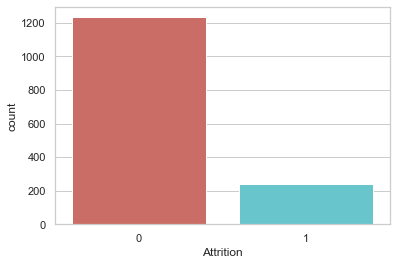

In [13]:
sns.countplot(x='Attrition', data=df, palette='hls')
plt.show()
# plt. savefig('count plot')

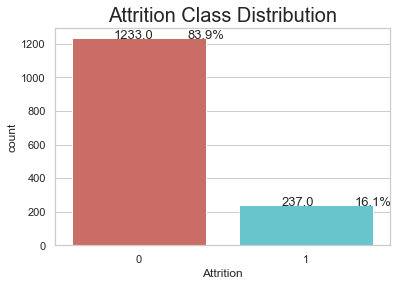

In [14]:
total = float(len(df))
ax = sns.countplot(x='Attrition', data=df, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()



# Decision Tree

## Training a Decision Tree Model
- Use DecisionTreeClassifier in sklearn 
- Some paramters: 
    - criterion: The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.
    - max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    - min_samples_leaf: The minimum number of samples required to be at a leaf node. 
    - max_features: The number of features to consider when looking for the best split:
    - see all parameters in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### 1. Balancing the DV (Attrition) with our IV's

In [15]:
# Replicate original data so not to overwrite it 
df1 = df.copy()
dfs = df.copy()


df1 #[1470 rows × 31 columns]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,1,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,3,0,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,1,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,1,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,3,1,...,3,2,2,17,3,2,7,7,7,7


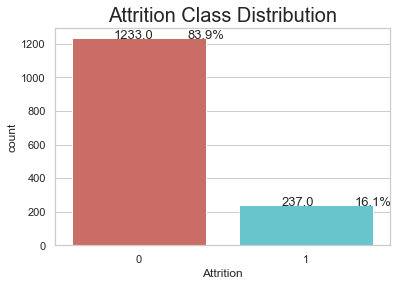

In [16]:
total = float(len(df1))
ax = sns.countplot(x='Attrition', data=df1, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

In [17]:
df1

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,1,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,3,0,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,1,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,1,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,3,1,...,3,2,2,17,3,2,7,7,7,7


In [18]:
# create dummy variables for each country using function pd.get_dummies() for variable 'Country'
# add a prefix to names of dummies using 'prefix='Country'
# embed pd.get_dummies(ad_data2['Country'], prefix='Country') inside pd.conat()

# another way:
# countries = pd.get_dummies(ad_data2['Country'], prefix='Country')
# ad_data2 = pd.concat([ad_data2, countries],axis=1)


##-----BusinessTravel------###
df1 = pd.concat([df1, pd.get_dummies(df1['BusinessTravel'], prefix='BusinessTravel')],axis=1)
##-----Department------###
df1 = pd.concat([df1, pd.get_dummies(df1['Department'], prefix='Department')],axis=1)
##-----EducationField------###
df1 = pd.concat([df1, pd.get_dummies(df1['EducationField'], prefix='EducationField')],axis=1)
##-----JobRole------###
df1 = pd.concat([df1, pd.get_dummies(df1['JobRole'], prefix='JobRole')],axis=1)
##-----MaritalStatus------###
df1 = pd.concat([df1, pd.get_dummies(df1['MaritalStatus'], prefix='MaritalStatus')],axis=1)

In [19]:
### now drop the original 'country' column (you don't need it anymore)


##-----BusinessTravel------###
df1.drop(['BusinessTravel'],axis=1, inplace=True)
##-----Department------###
df1.drop(['Department'],axis=1, inplace=True)

##-----EducationField------###
df1.drop(['EducationField'],axis=1, inplace=True)

##-----JobRole------###
df1.drop(['JobRole'],axis=1, inplace=True)

##-----MaritalStatus------###
df1.drop(['MaritalStatus'],axis=1, inplace=True)


In [20]:
df1.info()
df1

# 1470 rows × 50 columns w/ Attrition(DV)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 50 columns):
Age                                  1470 non-null int64
Attrition                            1470 non-null int64
DailyRate                            1470 non-null int64
DistanceFromHome                     1470 non-null int64
Education                            1470 non-null int64
EnvironmentSatisfaction              1470 non-null int64
Gender                               1470 non-null int64
HourlyRate                           1470 non-null int64
JobInvolvement                       1470 non-null int64
JobLevel                             1470 non-null int64
JobSatisfaction                      1470 non-null int64
MonthlyIncome                        1470 non-null int64
MonthlyRate                          1470 non-null int64
NumCompaniesWorked                   1470 non-null int64
OverTime                             1470 non-null int64
PercentSalaryHike                    1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [21]:
df1.columns
# 1470 rows × 50 columns



Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Re

In [22]:
df1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [23]:
# Create a list of predictor (x) variables: just Age
predictors1 = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single']


# Create another list of predictor variables: Age, Country dummies (without the first country dummy) 
# [i for i in ad_data2.columns if i.startswith('Country')]: chooses all items in ad_data2.columns (var names)
# which start with 'Country'
# [i for i in ad_data2.columns if i.startswith('Country')][1:] -> add all countries but the first one (drop country at index 0)


###########predictors2 = ['Age']+[i for i in df1.columns if i.startswith('BusinessTravel')][1:]+[i for i in df1.columns if i.startswith('Department')][1:]+[i for i in df1.columns if i.startswith('EducationField')][1:]+[i for i in df1.columns if i.startswith('JobRole')][1:]+[i for i in df1.columns if i.startswith('MaritalStatus')][1:]


##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###




In [24]:
# create dataframes for X (using Age only) and y variables 
X = df1[predictors1] # choose predictors1
y = df1['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRol

### Unbalanced DV: Over-Sampling with SMOTE

SMOTE: Synthetic Minority Over sampling Technique (SMOTE) algorithm applies KNN approach where it selects K nearest neighbors, joins them and creates the synthetic samples in the space. The algorithm takes the feature vectors and its nearest neighbors, computes the distance between these vectors. The difference is multiplied by random number between (0, 1) and it is added back to feature. SMOTE algorithm is a pioneer algorithm and many other algorithms are derived from SMOTE.


In [25]:
# extract new x-vars after dimensionality reduction
X = df1[predictors1]
y = df1['Attrition']

# X = [1470 rows × 49 columns/IVs]
# y = [1470 rows × 1 column/DV]

In [26]:
# X
# y

# X = [1470 rows × 51 columns/IVs]
# y = [1470 rows × 1 column/DV]

In [27]:
sm = SMOTE(random_state=101)
X_res, y_res = sm.fit_resample(X, y)

In [28]:
# split data into train/test data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state = 101)

model = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('SMOTE - Decision Tree Classifier', y_pred, y_test)

______________________________________________
Model: SMOTE - Decision Tree Classifier
Accuracy: 0.8243243243243243
Precision: 0.8230337078651685
Recall: 0.8138888888888889
F1-score: 0.8184357541899441
AUC: 0.8240497076023392
______________________________________________



In [29]:
SMOTElabels = pd.DataFrame(y_res) # label is the value of the target var
SMOTEfeatures = pd.DataFrame (X_res)

In [30]:
SMOTEdata = pd.concat([SMOTElabels, SMOTEfeatures], axis=1)
SMOTEdata

print(isinstance(SMOTEdata, pd.DataFrame))

SMOTEdata.to_csv('HR_Attrition_IBM.csv')


# [2466 rows × 52 columns]



True


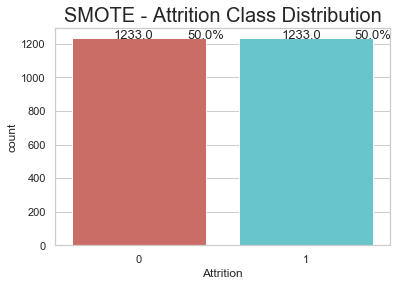

In [31]:
total = float(len(SMOTEdata))
ax = sns.countplot(x='Attrition', data=SMOTEdata, palette='hls')
plt.title('SMOTE - Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

### Unbalanced DV: Over-Sampling with ADASYN

ADAptive SYNthetic (ADASYN) is based on the idea of adaptively generating minority data samples according to their distributions using K nearest neighbor. The algorithm adaptively updates the distribution and there are no assumptions made for the underlying distribution of the data.  The algorithm uses Euclidean distance for KNN Algorithm. The key difference between ADASYN and SMOTE is that the former uses a density distribution, as a criterion to automatically decide the number of synthetic samples that must be generated for each minority sample by adaptively changing the weights of the different minority samples to compensate for the skewed distributions. The latter generates the same number of synthetic samples for each original minority sample.

In [32]:
# extract new x-vars after dimensionality reduction
X = df1[predictors1]
y = df1['Attrition']

# X = [1470 rows × 51 columns/IVs]
# y = [1470 rows × 1 column/DV]

In [33]:
ada = ADASYN(random_state=101)
X_res, y_res = ada.fit_resample(X, y)


In [34]:
# split data into train/test data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state = 101)

model = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('ADASYN - Decision Tree Classifier', y_pred, y_test)

______________________________________________
Model: ADASYN - Decision Tree Classifier
Accuracy: 0.8286908077994429
Precision: 0.807909604519774
Recall: 0.8387096774193549
F1-score: 0.8230215827338131
AUC: 0.8291691623171046
______________________________________________



In [35]:
ADAlabels = pd.DataFrame(y_res) # label is the value of the target var
ADAfeatures = pd.DataFrame (X_res)

In [36]:
ADAdata = pd.concat([ADAlabels, ADAfeatures], axis=1)
ADAdata

# [2406 rows × 52 columns]



,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [37]:
ADAdata = pd.concat([ADAlabels, ADAfeatures], axis=1)
ADAdata

print(isinstance(ADAdata, pd.DataFrame))

ADAdata.to_csv('HR_Attrition_IBM.csv')


# [2406 rows × 52 columns]



True


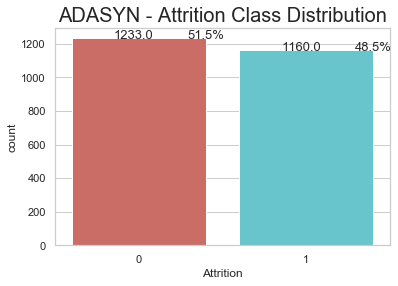

In [38]:
total = float(len(ADAdata))
ax = sns.countplot(x='Attrition', data=ADAdata, palette='hls')
plt.title('ADASYN - Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

# Standarizing ALL non-Categorical Predictors

### SMOTE Data

In [39]:
SMOTEdata

,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [40]:
df = SMOTEdata.copy()
df

,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [41]:
print(isinstance(df, pd.DataFrame))
df


True


,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [42]:
df.columns

Index(['Attrition', 'Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Re

In [43]:
# # # All 49 Predictors: ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
#        'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
#        'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
#        'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
#        'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
#        'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
#        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
#        'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
#        'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
#        'Department_Human Resources', 'Department_Research & Development',
#        'Department_Sales', 'EducationField_Human Resources',
#        'EducationField_Life Sciences', 'EducationField_Marketing',
#        'EducationField_Medical', 'EducationField_Other',
#        'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
#        'JobRole_Human Resources', 'JobRole_Laboratory Technician',
#        'JobRole_Manager', 'JobRole_Manufacturing Director',
#        'JobRole_Research Director', 'JobRole_Research Scientist',
#        'JobRole_Sales Executive', 'JobRole_Sales Representative',
#        'MaritalStatus_Divorced', 'MaritalStatus_Married',
#        'MaritalStatus_Single']



In [44]:
# Categorical Predictors -- NO standardization Needed
#-----OverTime------###
#-----Gender------#### 
##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###

In [45]:
# Continuous Predictors -- Standardization Needed
#-----Age------###
#-----DailyRate------###
#-----DistanceFromHome------###
#-----Education------###
#-----EnvironmentSatisfaction------###
#-----HourlyRate------###
#-----JobInvolvement------###
#-----JobLevel------###
#-----JobSatisfaction------###
#-----MonthlyIncome------###
#-----MonthlyRate------###
#-----NumCompaniesWorked------###
#-----PercentSalaryHike------###
#-----PerformanceRating------###
#-----RelationshipSatisfaction------###
#-----StockOptionLevel------###
#-----TotalWorkingYears------###
#-----TrainingTimesLastYear------###
#-----WorkLifeBalance------###
#-----YearsAtCompany------###
#-----YearsInCurrentRole------###
#-----YearsSinceLastPromotion------###
#-----YearsWithCurrManager------###




In [46]:
df.columns

Index(['Attrition', 'Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Re

In [47]:
CF = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

BF = ['Attrition','Gender', 'OverTime', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single']


In [48]:
features = df[CF] # choose predictors to standardize
y = df[BF] # choose rest features+DV

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRol

In [49]:
features = preprocessing.scale(features)
features

array([[ 0.61731495,  0.86054991, -1.11659336, ...,  0.13633351,
        -0.65465008,  0.46255073],
       [ 1.5065081 , -1.3018022 , -0.19550789, ...,  1.03047826,
        -0.32179088,  1.06590967],
       [ 0.17271838,  1.57257593, -0.98500972, ..., -1.0558595 ,
        -0.65465008, -1.04584664],
       ...,
       [ 0.06156923, -0.36119217, -0.85342608, ..., -1.0558595 ,
        -0.65465008, -0.74416717],
       [-1.0499222 ,  0.26938438, -0.85342608, ..., -0.45976299,
        -0.32179088, -0.44248769],
       [-0.60532563, -0.164137  , -0.98500972, ..., -1.0558595 ,
        -0.65465008, -1.04584664]])

In [50]:
features = pd.DataFrame (features)

In [51]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 23 columns):
0     2466 non-null float64
1     2466 non-null float64
2     2466 non-null float64
3     2466 non-null float64
4     2466 non-null float64
5     2466 non-null float64
6     2466 non-null float64
7     2466 non-null float64
8     2466 non-null float64
9     2466 non-null float64
10    2466 non-null float64
11    2466 non-null float64
12    2466 non-null float64
13    2466 non-null float64
14    2466 non-null float64
15    2466 non-null float64
16    2466 non-null float64
17    2466 non-null float64
18    2466 non-null float64
19    2466 non-null float64
20    2466 non-null float64
21    2466 non-null float64
22    2466 non-null float64
dtypes: float64(23)
memory usage: 443.2 KB


In [52]:
features.columns =['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

# 23 columns


In [53]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 23 columns):
Age                         2466 non-null float64
DailyRate                   2466 non-null float64
DistanceFromHome            2466 non-null float64
Education                   2466 non-null float64
EnvironmentSatisfaction     2466 non-null float64
HourlyRate                  2466 non-null float64
JobInvolvement              2466 non-null float64
JobLevel                    2466 non-null float64
JobSatisfaction             2466 non-null float64
MonthlyIncome               2466 non-null float64
MonthlyRate                 2466 non-null float64
NumCompaniesWorked          2466 non-null float64
PercentSalaryHike           2466 non-null float64
PerformanceRating           2466 non-null float64
RelationshipSatisfaction    2466 non-null float64
StockOptionLevel            2466 non-null float64
TotalWorkingYears           2466 non-null float64
TrainingTimesLastYear       2466 non-null f

In [54]:
labels = pd.DataFrame(y) # convert non standardized features to DF

In [55]:
data = pd.concat([labels, features], axis=1)
data

,Attrition,Gender,OverTime,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,0,1,0,0,1,0,0,1,0,...,-0.331377,-1.436408,-0.749437,-0.249448,-2.132817,-2.219243,-0.014188,0.136334,-0.654650,0.462551
1,0,1,0,0,1,0,0,1,0,0,...,3.017707,1.420959,0.514661,0.018586,0.346532,0.548217,0.668493,1.030478,-0.321791,1.065910
2,1,1,1,0,0,1,0,1,0,0,...,-0.331377,-0.483953,-0.749437,-0.383465,0.346532,0.548217,-1.038209,-1.055859,-0.654650,-1.045847
3,0,0,1,0,1,0,0,1,0,0,...,-0.331377,0.468503,-0.749437,-0.249448,0.346532,0.548217,0.327152,1.030478,0.343928,-1.045847
4,0,1,0,0,0,1,0,1,0,0,...,-0.331377,1.420959,0.514661,-0.517482,0.346532,0.548217,-0.696868,-0.459763,0.011068,-0.442488
5,0,1,0,0,1,0,0,1,0,0,...,-0.331377,0.468503,-0.749437,-0.249448,-0.479917,-0.835513,0.156482,1.030478,0.343928,0.764230
6,0,0,1,0,0,1,0,1,0,0,...,3.017707,-1.436408,3.042856,0.286621,0.346532,-0.835513,-0.867539,-1.055859,-0.654650,-1.045847
7,0,1,0,0,0,1,0,1,0,0,...,3.017707,-0.483953,0.514661,-1.187568,-0.479917,0.548217,-0.867539,-1.055859,-0.654650,-1.045847
8,0,1,0,0,1,0,0,1,0,0,...,3.017707,-0.483953,-0.749437,0.018586,-0.479917,0.548217,0.497822,1.030478,-0.321791,1.367589
9,0,1,0,0,0,1,0,1,0,0,...,-0.331377,-0.483953,1.778759,0.956706,0.346532,-0.835513,0.156482,1.030478,1.675364,1.065910


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 50 columns):
Attrition                            2466 non-null int64
Gender                               2466 non-null int64
OverTime                             2466 non-null int64
BusinessTravel_Non-Travel            2466 non-null uint8
BusinessTravel_Travel_Frequently     2466 non-null uint8
BusinessTravel_Travel_Rarely         2466 non-null uint8
Department_Human Resources           2466 non-null uint8
Department_Research & Development    2466 non-null uint8
Department_Sales                     2466 non-null uint8
EducationField_Human Resources       2466 non-null uint8
EducationField_Life Sciences         2466 non-null uint8
EducationField_Marketing             2466 non-null uint8
EducationField_Medical               2466 non-null uint8
EducationField_Other                 2466 non-null uint8
EducationField_Technical Degree      2466 non-null uint8
JobRole_Healthcare Representative    2

In [57]:
data.to_csv('St_SMOTE_HR_Data.csv')


### ADASYN Data

In [58]:
ADAdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 50 columns):
Attrition                            2393 non-null int64
Age                                  2393 non-null int64
DailyRate                            2393 non-null int64
DistanceFromHome                     2393 non-null int64
Education                            2393 non-null int64
EnvironmentSatisfaction              2393 non-null int64
Gender                               2393 non-null int64
HourlyRate                           2393 non-null int64
JobInvolvement                       2393 non-null int64
JobLevel                             2393 non-null int64
JobSatisfaction                      2393 non-null int64
MonthlyIncome                        2393 non-null int64
MonthlyRate                          2393 non-null int64
NumCompaniesWorked                   2393 non-null int64
OverTime                             2393 non-null int64
PercentSalaryHike                    2

In [59]:
df = ADAdata.copy()
df

,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [60]:
print(isinstance(df, pd.DataFrame))
df


True


,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,4,1,79,3,1,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,3,0,81,4,1,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,4,1,67,3,1,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,4,1,44,2,3,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,3,1,94,3,2,...,0,0,0,0,0,0,0,0,1,0


In [61]:
df.columns

Index(['Attrition', 'Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Re

In [62]:
# # # All 49 Predictors: ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
#        'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
#        'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
#        'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
#        'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
#        'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
#        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
#        'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
#        'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
#        'Department_Human Resources', 'Department_Research & Development',
#        'Department_Sales', 'EducationField_Human Resources',
#        'EducationField_Life Sciences', 'EducationField_Marketing',
#        'EducationField_Medical', 'EducationField_Other',
#        'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
#        'JobRole_Human Resources', 'JobRole_Laboratory Technician',
#        'JobRole_Manager', 'JobRole_Manufacturing Director',
#        'JobRole_Research Director', 'JobRole_Research Scientist',
#        'JobRole_Sales Executive', 'JobRole_Sales Representative',
#        'MaritalStatus_Divorced', 'MaritalStatus_Married',
#        'MaritalStatus_Single']



In [63]:
# Categorical Predictors -- NO standardization Needed
#-----OverTime------###
#-----Gender------#### 
##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###

In [64]:
# Continuous Predictors -- Standardization Needed
#-----Age------###
#-----DailyRate------###
#-----DistanceFromHome------###
#-----Education------###
#-----EnvironmentSatisfaction------###
#-----HourlyRate------###
#-----JobInvolvement------###
#-----JobLevel------###
#-----JobSatisfaction------###
#-----MonthlyIncome------###
#-----MonthlyRate------###
#-----NumCompaniesWorked------###
#-----PercentSalaryHike------###
#-----PerformanceRating------###
#-----RelationshipSatisfaction------###
#-----StockOptionLevel------###
#-----TotalWorkingYears------###
#-----TrainingTimesLastYear------###
#-----WorkLifeBalance------###
#-----YearsAtCompany------###
#-----YearsInCurrentRole------###
#-----YearsSinceLastPromotion------###
#-----YearsWithCurrManager------###




In [65]:
df.columns

Index(['Attrition', 'Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Re

In [66]:
CF = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

BF = ['Attrition','Gender', 'OverTime', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single']


In [67]:
features = df[CF] # choose predictors to standardize
y = df[BF] # choose rest features+DV

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRol

In [68]:
features = preprocessing.scale(features)
features

array([[ 0.60785014,  0.84253276, -1.11868678, ...,  0.11443422,
        -0.66332458,  0.44186   ],
       [ 1.50422073, -1.31836529, -0.20239309, ...,  1.00642476,
        -0.33427489,  1.04469407],
       [ 0.15966484,  1.55407999, -0.98778768, ..., -1.0748865 ,
        -0.66332458, -1.06522519],
       ...,
       [ 1.39217441, -1.00066339,  1.63019429, ..., -0.18289596,
        -0.00522519, -1.06522519],
       [ 1.50422073, -0.78798691,  2.28468978, ..., -0.77755632,
        -0.33427489, -1.06522519],
       [ 0.60785014,  1.49894165,  1.89199249, ..., -1.0748865 ,
        -0.66332458, -1.06522519]])

In [69]:
features = pd.DataFrame (features)

In [70]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 23 columns):
0     2393 non-null float64
1     2393 non-null float64
2     2393 non-null float64
3     2393 non-null float64
4     2393 non-null float64
5     2393 non-null float64
6     2393 non-null float64
7     2393 non-null float64
8     2393 non-null float64
9     2393 non-null float64
10    2393 non-null float64
11    2393 non-null float64
12    2393 non-null float64
13    2393 non-null float64
14    2393 non-null float64
15    2393 non-null float64
16    2393 non-null float64
17    2393 non-null float64
18    2393 non-null float64
19    2393 non-null float64
20    2393 non-null float64
21    2393 non-null float64
22    2393 non-null float64
dtypes: float64(23)
memory usage: 430.1 KB


In [71]:
features.columns =['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

# 23 columns


In [72]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 23 columns):
Age                         2393 non-null float64
DailyRate                   2393 non-null float64
DistanceFromHome            2393 non-null float64
Education                   2393 non-null float64
EnvironmentSatisfaction     2393 non-null float64
HourlyRate                  2393 non-null float64
JobInvolvement              2393 non-null float64
JobLevel                    2393 non-null float64
JobSatisfaction             2393 non-null float64
MonthlyIncome               2393 non-null float64
MonthlyRate                 2393 non-null float64
NumCompaniesWorked          2393 non-null float64
PercentSalaryHike           2393 non-null float64
PerformanceRating           2393 non-null float64
RelationshipSatisfaction    2393 non-null float64
StockOptionLevel            2393 non-null float64
TotalWorkingYears           2393 non-null float64
TrainingTimesLastYear       2393 non-null f

In [73]:
labels = pd.DataFrame(y) # convert non standardized features to DF

In [74]:
data = pd.concat([labels, features], axis=1)
data

,Attrition,Gender,OverTime,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,0,1,0,0,1,0,0,1,0,...,-0.337727,-1.448450,-0.742835,-0.266982,-2.132711,-2.174445,-0.032576,0.114434,-0.663325,0.441860
1,0,1,0,0,1,0,0,1,0,0,...,2.960971,1.414552,0.513423,0.000447,0.340751,0.546312,0.643810,1.006425,-0.334275,1.044694
2,1,1,1,0,0,1,0,1,0,0,...,-0.337727,-0.494116,-0.742835,-0.400696,0.340751,0.546312,-1.047153,-1.074886,-0.663325,-1.065225
3,0,0,1,0,1,0,0,1,0,0,...,-0.337727,0.460218,-0.742835,-0.266982,0.340751,0.546312,0.305617,1.006425,0.323824,-1.065225
4,0,1,0,0,0,1,0,1,0,0,...,-0.337727,1.414552,0.513423,-0.534411,0.340751,0.546312,-0.708961,-0.480226,-0.005225,-0.462391
5,0,1,0,0,1,0,0,1,0,0,...,-0.337727,0.460218,-0.742835,-0.266982,-0.483736,-0.814067,0.136521,1.006425,0.323824,0.743277
6,0,0,1,0,0,1,0,1,0,0,...,2.960971,-1.448450,3.025939,0.267876,0.340751,-0.814067,-0.878057,-1.074886,-0.663325,-1.065225
7,0,1,0,0,0,1,0,1,0,0,...,2.960971,-0.494116,0.513423,-1.202983,-0.483736,0.546312,-0.878057,-1.074886,-0.663325,-1.065225
8,0,1,0,0,1,0,0,1,0,0,...,2.960971,-0.494116,-0.742835,0.000447,-0.483736,0.546312,0.474713,1.006425,-0.334275,1.346111
9,0,1,0,0,0,1,0,1,0,0,...,-0.337727,-0.494116,1.769681,0.936448,0.340751,-0.814067,0.136521,1.006425,1.640023,1.044694


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 50 columns):
Attrition                            2393 non-null int64
Gender                               2393 non-null int64
OverTime                             2393 non-null int64
BusinessTravel_Non-Travel            2393 non-null uint8
BusinessTravel_Travel_Frequently     2393 non-null uint8
BusinessTravel_Travel_Rarely         2393 non-null uint8
Department_Human Resources           2393 non-null uint8
Department_Research & Development    2393 non-null uint8
Department_Sales                     2393 non-null uint8
EducationField_Human Resources       2393 non-null uint8
EducationField_Life Sciences         2393 non-null uint8
EducationField_Marketing             2393 non-null uint8
EducationField_Medical               2393 non-null uint8
EducationField_Other                 2393 non-null uint8
EducationField_Technical Degree      2393 non-null uint8
JobRole_Healthcare Representative    2

In [76]:
data.to_csv('St_ADASYN_HR_Data.csv')


# Decision Tree Model - Standardized SMOTE Data

In [77]:
#import data 
df = pd.read_csv('St_SMOTE_HR_Data.csv')
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 51 columns):
Unnamed: 0                           2466 non-null int64
Attrition                            2466 non-null int64
Gender                               2466 non-null int64
OverTime                             2466 non-null int64
BusinessTravel_Non-Travel            2466 non-null int64
BusinessTravel_Travel_Frequently     2466 non-null int64
BusinessTravel_Travel_Rarely         2466 non-null int64
Department_Human Resources           2466 non-null int64
Department_Research & Development    2466 non-null int64
Department_Sales                     2466 non-null int64
EducationField_Human Resources       2466 non-null int64
EducationField_Life Sciences         2466 non-null int64
EducationField_Marketing             2466 non-null int64
EducationField_Medical               2466 non-null int64
EducationField_Other                 2466 non-null int64
EducationField_Technical Degree      2

Index(['Unnamed: 0', 'Attrition', 'Gender', 'OverTime',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single', 'Age', 'DailyRate',
       'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction

In [78]:
# ---Removing Variable - "Unnamed: 0" - Saved Index--#
df = df.drop('Unnamed: 0', axis=1) # axis=1 indicates that 'new' is a column 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 50 columns):
Attrition                            2466 non-null int64
Gender                               2466 non-null int64
OverTime                             2466 non-null int64
BusinessTravel_Non-Travel            2466 non-null int64
BusinessTravel_Travel_Frequently     2466 non-null int64
BusinessTravel_Travel_Rarely         2466 non-null int64
Department_Human Resources           2466 non-null int64
Department_Research & Development    2466 non-null int64
Department_Sales                     2466 non-null int64
EducationField_Human Resources       2466 non-null int64
EducationField_Life Sciences         2466 non-null int64
EducationField_Marketing             2466 non-null int64
EducationField_Medical               2466 non-null int64
EducationField_Other                 2466 non-null int64
EducationField_Technical Degree      2466 non-null int64
JobRole_Healthcare Representative    2

In [79]:
df.Attrition.value_counts()
# balanced DV check

1    1233
0    1233
Name: Attrition, dtype: int64

In [80]:
df

,Attrition,Gender,OverTime,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,0,1,0,0,1,0,0,1,0,...,-0.331377,-1.436408,-0.749437,-0.249448,-2.132817,-2.219243,-0.014188,0.136334,-0.654650,0.462551
1,0,1,0,0,1,0,0,1,0,0,...,3.017707,1.420959,0.514661,0.018586,0.346532,0.548217,0.668493,1.030478,-0.321791,1.065910
2,1,1,1,0,0,1,0,1,0,0,...,-0.331377,-0.483953,-0.749437,-0.383465,0.346532,0.548217,-1.038209,-1.055859,-0.654650,-1.045847
3,0,0,1,0,1,0,0,1,0,0,...,-0.331377,0.468503,-0.749437,-0.249448,0.346532,0.548217,0.327152,1.030478,0.343928,-1.045847
4,0,1,0,0,0,1,0,1,0,0,...,-0.331377,1.420959,0.514661,-0.517482,0.346532,0.548217,-0.696868,-0.459763,0.011068,-0.442488
5,0,1,0,0,1,0,0,1,0,0,...,-0.331377,0.468503,-0.749437,-0.249448,-0.479917,-0.835513,0.156482,1.030478,0.343928,0.764230
6,0,0,1,0,0,1,0,1,0,0,...,3.017707,-1.436408,3.042856,0.286621,0.346532,-0.835513,-0.867539,-1.055859,-0.654650,-1.045847
7,0,1,0,0,0,1,0,1,0,0,...,3.017707,-0.483953,0.514661,-1.187568,-0.479917,0.548217,-0.867539,-1.055859,-0.654650,-1.045847
8,0,1,0,0,1,0,0,1,0,0,...,3.017707,-0.483953,-0.749437,0.018586,-0.479917,0.548217,0.497822,1.030478,-0.321791,1.367589
9,0,1,0,0,0,1,0,1,0,0,...,-0.331377,-0.483953,1.778759,0.956706,0.346532,-0.835513,0.156482,1.030478,1.675364,1.065910


In [81]:
count_no_At = len(df[df['Attrition']==0])
count_At = len(df[df['Attrition']==1])
pct_of_no_At = count_no_At/(count_no_At+count_At)
print("percentage of no Attrition is", pct_of_no_At*100)
pct_of_At = count_At/(count_no_At+count_At)
print("percentage of Attrition", pct_of_At*100)

percentage of no Attrition is 50.0
percentage of Attrition 50.0


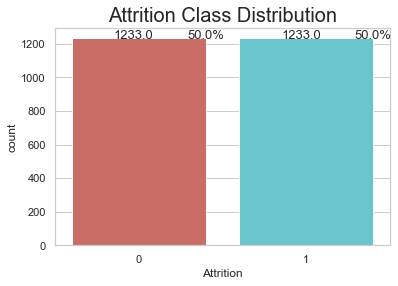

In [82]:
total = float(len(df))
ax = sns.countplot(x='Attrition', data=df, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()



In [83]:
# Specify Predictors 

predictors1 = ['Gender', 'OverTime', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single','Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']





In [84]:
# creating dataframes for X and y variables 

X = df[predictors1] # choose predictors1
y = df['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Gender', 'OverTime', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatis

In [85]:
# Split data - test_size of 30%, random_state=101
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101, stratify=y)


In [86]:
X_train.head()
y_train.head()

1694    1
715     0
2391    1
277     0
2234    1
Name: Attrition, dtype: int64

In [87]:
# train model, set criterion, max_depth=5 (no tree over 5 levels)
model_dt = DecisionTreeClassifier(criterion='entropy', random_state=101)

# fit the model
model_dt.fit(X_train, y_train)


y_pred = model_dt.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

print('confusion matrix: \n', confusion_matrix_results)

display_metrics('S_SMOTE - Decision Tree Classifier', y_pred, y_test)


confusion matrix: 
 [[308  60]
 [ 62 310]]
______________________________________________
Model: S_SMOTE - Decision Tree Classifier
Accuracy: 0.8351351351351352
Precision: 0.8333333333333334
Recall: 0.8378378378378378
F1-score: 0.8355795148247978
AUC: 0.835135135135135
______________________________________________



In [88]:
# train model, set criterion, max_depth=5 (no tree over 5 levels)
model_dt5 = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)

# fit the model
model_dt5.fit(X_train, y_train)


y_pred = model_dt5.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)
print('confusion matrix: \n', confusion_matrix_results)

display_metrics('S_SMOTE - Decision Tree Classifier', y_pred, y_test)



confusion matrix: 
 [[288  62]
 [ 82 308]]
______________________________________________
Model: S_SMOTE - Decision Tree Classifier
Accuracy: 0.8054054054054054
Precision: 0.7897435897435897
Recall: 0.8324324324324325
F1-score: 0.8105263157894738
AUC: 0.8054054054054054
______________________________________________



## Training a Decision Tree Model
- Use DecisionTreeClassifier in sklearn 
- Some paramters: 
    - criterion: The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.
    - max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    - min_samples_leaf: The minimum number of samples required to be at a leaf node. 
    - max_features: The number of features to consider when looking for the best split:
    - see all parameters in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Feature Importance

Feature ranking:
                        Feature Total Reduction of Criterion
0              StockOptionLevel                    0.0946451
1               JobSatisfaction                     0.064603
2      RelationshipSatisfaction                    0.0590042
3  EducationField_Life Sciences                    0.0555566
4                 MonthlyIncome                    0.0535147
5                   MonthlyRate                     0.048575
6        EducationField_Medical                    0.0441154
7         MaritalStatus_Married                    0.0437261
8                JobInvolvement                    0.0405248
9            YearsInCurrentRole                    0.0337856


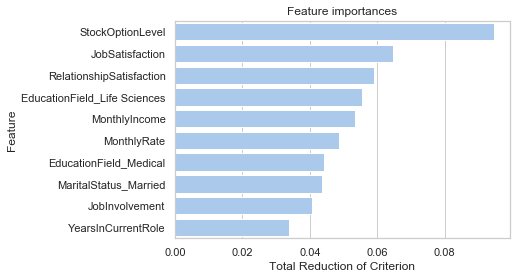

In [89]:
# visualize x-vars by importance
importances = model_dt.feature_importances_  # extract importance metrics 
indices = np.argsort(importances)[::-1] # sorts the rows 

print("Feature ranking:")

feature_names = X_train.columns 

# create a dataframe using Pandas for the vars using pd.DataFrame() using feature names and importance metrics
fi = pd.DataFrame([feature_names[indices[0:10]], importances[indices][0:10]])
fi = fi.T
fi.columns = ['Feature', 'Total Reduction of Criterion']

print(fi)

# Plot the feature importances of the forest using seaborn
plt.figure()
plt.title("Feature importances")

sns.set_color_codes("pastel")
sns.barplot(x="Total Reduction of Criterion", y="Feature", data=fi, color="b")


## Predictions and Evaluation of Decision Tree

In [90]:
# use predict function to make predictions 
y_pred = model_dt.predict(X_test)

In [91]:
# calculate the confusion matrix for the test data 
confusion_matrix_results = confusion_matrix(y_test, y_pred)

# print the counts of the confusion matrix 
print('confusion matrix: \n', confusion_matrix_results)

# print the metrics 
display_metrics('Decision Tree', y_pred, y_test)


confusion matrix: 
 [[308  62]
 [ 60 310]]
______________________________________________
Model: Decision Tree
Accuracy: 0.8351351351351352
Precision: 0.8333333333333334
Recall: 0.8378378378378378
F1-score: 0.8355795148247978
AUC: 0.835135135135135
______________________________________________



In [92]:
# predict each instance's probability of survival for each individual using 'predict_proba' function
model_dt.predict_proba(X_train)


array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

# Decision Tree Model - Standardized ADASYN Data

In [93]:
#import data 
df = pd.read_csv('St_ADASYN_HR_Data.csv')
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 51 columns):
Unnamed: 0                           2393 non-null int64
Attrition                            2393 non-null int64
Gender                               2393 non-null int64
OverTime                             2393 non-null int64
BusinessTravel_Non-Travel            2393 non-null int64
BusinessTravel_Travel_Frequently     2393 non-null int64
BusinessTravel_Travel_Rarely         2393 non-null int64
Department_Human Resources           2393 non-null int64
Department_Research & Development    2393 non-null int64
Department_Sales                     2393 non-null int64
EducationField_Human Resources       2393 non-null int64
EducationField_Life Sciences         2393 non-null int64
EducationField_Marketing             2393 non-null int64
EducationField_Medical               2393 non-null int64
EducationField_Other                 2393 non-null int64
EducationField_Technical Degree      2

Index(['Unnamed: 0', 'Attrition', 'Gender', 'OverTime',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single', 'Age', 'DailyRate',
       'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction

In [94]:
# ---Removing Variable - "Unnamed: 0" - Saved Index--#
df = df.drop('Unnamed: 0', axis=1) # axis=1 indicates that 'new' is a column 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 50 columns):
Attrition                            2393 non-null int64
Gender                               2393 non-null int64
OverTime                             2393 non-null int64
BusinessTravel_Non-Travel            2393 non-null int64
BusinessTravel_Travel_Frequently     2393 non-null int64
BusinessTravel_Travel_Rarely         2393 non-null int64
Department_Human Resources           2393 non-null int64
Department_Research & Development    2393 non-null int64
Department_Sales                     2393 non-null int64
EducationField_Human Resources       2393 non-null int64
EducationField_Life Sciences         2393 non-null int64
EducationField_Marketing             2393 non-null int64
EducationField_Medical               2393 non-null int64
EducationField_Other                 2393 non-null int64
EducationField_Technical Degree      2393 non-null int64
JobRole_Healthcare Representative    2

In [95]:
df.Attrition.value_counts()
# balanced DV check

0    1233
1    1160
Name: Attrition, dtype: int64

In [96]:
df

,Attrition,Gender,OverTime,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,0,1,0,0,1,0,0,1,0,...,-0.337727,-1.448450,-0.742835,-0.266982,-2.132711,-2.174445,-0.032576,0.114434,-0.663325,0.441860
1,0,1,0,0,1,0,0,1,0,0,...,2.960971,1.414552,0.513423,0.000447,0.340751,0.546312,0.643810,1.006425,-0.334275,1.044694
2,1,1,1,0,0,1,0,1,0,0,...,-0.337727,-0.494116,-0.742835,-0.400696,0.340751,0.546312,-1.047153,-1.074886,-0.663325,-1.065225
3,0,0,1,0,1,0,0,1,0,0,...,-0.337727,0.460218,-0.742835,-0.266982,0.340751,0.546312,0.305617,1.006425,0.323824,-1.065225
4,0,1,0,0,0,1,0,1,0,0,...,-0.337727,1.414552,0.513423,-0.534411,0.340751,0.546312,-0.708961,-0.480226,-0.005225,-0.462391
5,0,1,0,0,1,0,0,1,0,0,...,-0.337727,0.460218,-0.742835,-0.266982,-0.483736,-0.814067,0.136521,1.006425,0.323824,0.743277
6,0,0,1,0,0,1,0,1,0,0,...,2.960971,-1.448450,3.025939,0.267876,0.340751,-0.814067,-0.878057,-1.074886,-0.663325,-1.065225
7,0,1,0,0,0,1,0,1,0,0,...,2.960971,-0.494116,0.513423,-1.202983,-0.483736,0.546312,-0.878057,-1.074886,-0.663325,-1.065225
8,0,1,0,0,1,0,0,1,0,0,...,2.960971,-0.494116,-0.742835,0.000447,-0.483736,0.546312,0.474713,1.006425,-0.334275,1.346111
9,0,1,0,0,0,1,0,1,0,0,...,-0.337727,-0.494116,1.769681,0.936448,0.340751,-0.814067,0.136521,1.006425,1.640023,1.044694


In [97]:
count_no_At = len(df[df['Attrition']==0])
count_At = len(df[df['Attrition']==1])
pct_of_no_At = count_no_At/(count_no_At+count_At)
print("percentage of no Attrition is", pct_of_no_At*100)
pct_of_At = count_At/(count_no_At+count_At)
print("percentage of Attrition", pct_of_At*100)

percentage of no Attrition is 51.52528207271207
percentage of Attrition 48.47471792728793


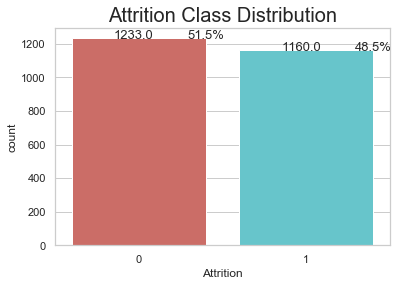

In [98]:
total = float(len(df))
ax = sns.countplot(x='Attrition', data=df, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()



In [99]:
# Specify Predictors 

predictors1 = ['Gender', 'OverTime', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single','Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']





In [100]:
# creating dataframes for X and y variables 

X = df[predictors1] # choose predictors1
y = df['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Gender', 'OverTime', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatis

In [101]:
# Split data - test_size of 30%, random_state=101
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101, stratify=y)


In [102]:
X_train.head()
y_train.head()

1807    1
1817    1
1550    1
2254    1
191     0
Name: Attrition, dtype: int64

In [103]:
# train model, set criterion, max_depth=5 (no tree over 5 levels)
model_dt = DecisionTreeClassifier(criterion='entropy', random_state=101)

# fit the model
model_dt.fit(X_train, y_train)


y_pred = model_dt.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('S_SMOTE - Decision Tree Classifier', y_pred, y_test)


______________________________________________
Model: S_SMOTE - Decision Tree Classifier
Accuracy: 0.8203342618384402
Precision: 0.8050139275766016
Recall: 0.8304597701149425
F1-score: 0.8175388967468175
AUC: 0.8206352904628765
______________________________________________



In [104]:
# train model, set criterion, max_depth=5 (no tree over 5 levels)
model_dt5 = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=500000)

# fit the model
model_dt5.fit(X_train, y_train)


y_pred = model_dt5.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('S_SMOTE - Decision Tree Classifier', y_pred, y_test)



______________________________________________
Model: S_SMOTE - Decision Tree Classifier
Accuracy: 0.8203342618384402
Precision: 0.8050139275766016
Recall: 0.8304597701149425
F1-score: 0.8175388967468175
AUC: 0.8206352904628765
______________________________________________



## Feature Importance

Feature ranking:
                             Feature Total Reduction of Criterion
0                   StockOptionLevel                      0.10747
1           RelationshipSatisfaction                    0.0658296
2                           JobLevel                    0.0596685
3  Department_Research & Development                    0.0489657
4                        MonthlyRate                    0.0482086
5                    JobSatisfaction                    0.0436079
6                 YearsInCurrentRole                    0.0414346
7   BusinessTravel_Travel_Frequently                     0.036707
8                                Age                    0.0362589
9       BusinessTravel_Travel_Rarely                    0.0361758


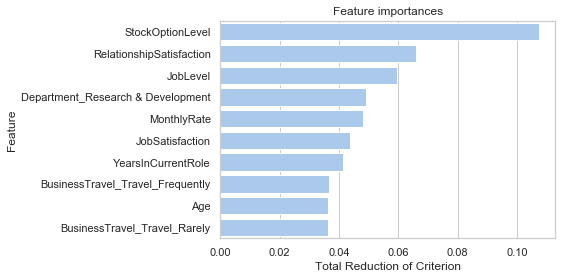

In [105]:
# visualize x-vars by importance
importances = model_dt.feature_importances_  # extract importance metrics 
indices = np.argsort(importances)[::-1] # sorts the rows 

print("Feature ranking:")

feature_names = X_train.columns 

# create a dataframe using Pandas for the vars using pd.DataFrame() using feature names and importance metrics
fi = pd.DataFrame([feature_names[indices[0:10]], importances[indices][0:10]])
fi = fi.T
fi.columns = ['Feature', 'Total Reduction of Criterion']

print(fi)

# Plot the feature importances of the forest using seaborn
plt.figure()
plt.title("Feature importances")

sns.set_color_codes("pastel")
sns.barplot(x="Total Reduction of Criterion", y="Feature", data=fi, color="b")


## Predictions and Evaluation of Decision Tree

In [106]:
# use predict function to make predictions 
y_pred = model_dt.predict(X_test)

In [107]:
# calculate the confusion matrix for the test data 
confusion_matrix_results = confusion_matrix(y_test, y_pred)

# print the counts of the confusion matrix 
print('confusion matrix: \n', confusion_matrix_results)

# print the metrics 
display_metrics('Decision Tree', y_pred, y_test)


confusion matrix: 
 [[300  70]
 [ 59 289]]
______________________________________________
Model: Decision Tree
Accuracy: 0.8203342618384402
Precision: 0.8050139275766016
Recall: 0.8304597701149425
F1-score: 0.8175388967468175
AUC: 0.8206352904628765
______________________________________________



In [108]:
# predict each instance's probability of survival for each individual using 'predict_proba' function
model_dt.predict_proba(X_train)


array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]])

[Text(189.75282935193945, 210.645, 'X[41] <= -0.115\ngini = 0.5\nsamples = 2393\nvalue = [1233, 1160]'),
 Text(125.66383041627248, 197.055, 'X[34] <= 0.928\ngini = 0.455\nsamples = 1361\nvalue = [477, 884]'),
 Text(94.61782166508988, 183.465, 'X[11] <= 0.5\ngini = 0.399\nsamples = 1145\nvalue = [315, 830]'),
 Text(68.47641911069063, 169.875, 'X[40] <= 0.937\ngini = 0.326\nsamples = 961\nvalue = [197, 764]'),
 Text(45.413386944181646, 156.285, 'X[9] <= 0.5\ngini = 0.247\nsamples = 824\nvalue = [119, 705]'),
 Text(24.943708609271525, 142.695, 'X[12] <= 0.5\ngini = 0.145\nsamples = 597\nvalue = [47, 550]'),
 Text(16.945884578997163, 129.10500000000002, 'X[13] <= 0.5\ngini = 0.111\nsamples = 578\nvalue = [34, 544]'),
 Text(7.918637653736991, 115.515, 'X[10] <= 0.5\ngini = 0.061\nsamples = 543\nvalue = [17, 526]'),
 Text(2.5339640491958373, 101.925, 'X[8] <= 0.5\ngini = 0.008\nsamples = 505\nvalue = [2, 503]'),
 Text(1.2669820245979186, 88.33500000000001, 'gini = 0.0\nsamples = 501\nvalue =

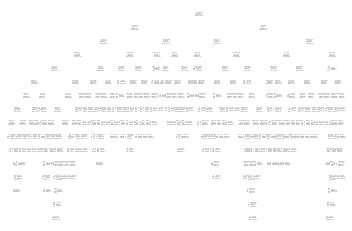

In [109]:
clf = tree.DecisionTreeClassifier(random_state=101)
clf = clf.fit(df[predictors1],df['Attrition'])
tree.plot_tree(clf)

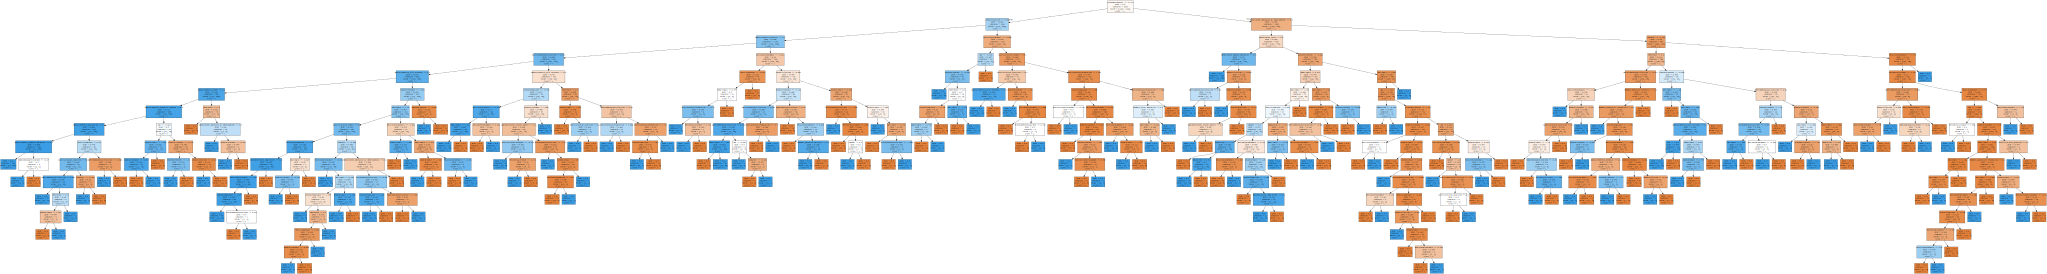

In [110]:
import graphviz
df = tree.export_graphviz(clf, out_file=None, 
                                feature_names=predictors1,  
                                class_names='Attrition',
                                filled=True)

# Draw graph
graph = graphviz.Source(df, format="png") 
graph

